# 05_01 LightGBM architecture comparison

Compare four global LightGBM architectures—daily L2, daily Tweedie, two-stage occurrence × positive quantity, and a seven-day total Tweedie model followed by historical weekday allocation—against the primary benchmark from `03_01` and all extended baselines from `04_01`. Every model is evaluated on the same series, rolling origins, seven-day horizon, and target rows.

## Shared design

The target is `ABVERKAUFTE_MENGE_KG`. All four LightGBM architectures are **refitted independently at every forecast origin**. Origins are spaced 28 days apart and each forecast covers seven days. At the first origin Q, 12 fully observed historical origins are available: 10 are used for fitting and the two most recent for validation and early stopping. At the next origin Q+28 days, the completed Q…Q+6 window enters history, giving 11 fitting origins and again two validation origins; the fitting window then continues to expand by one. The forecast origin itself remains untouched until prediction.

Demand-history features are strictly pre-origin. The known action schedule contributes `action_on_forecast_day` and `action_during_horizon`; `days_since_last_action`, the count `actions_last_28d`, and `mean_action_lift_in_sourcing_group` use only observations before the origin. The sourcing-group lift is the historical mean demand on action rows divided by the mean on non-action rows, minus one. ADI, CV², and zero share are numeric features; FCM/Pseudo and 890/900 remain identifier features and reporting segments. The weekly model is trained on series-origin totals and its daily allocations sum exactly to the predicted seven-day total.

The comparison keeps the model roles separate: `PRIMARY_MODEL` is the fixed benchmark selected in `03_01`; `BASELINE_MODEL_LABELS` contains the extended statistical baselines evaluated in `04_01`; and the best non-ML reference is selected only from those prespecified candidates.

![Expanding-origin LightGBM forecasting design](../../reports/figures/lightgbm_expanding_origin_design.svg)

The two-origin validation window rolls forward, while every newly completed forecast window enlarges the fitting set used by the next refit. Within a window, all seven predictions are made directly at Q: the one-day-ahead Q+1 row uses `horizon_day = 2` and Q+1 calendar features, but its demand-history features still use observations only through Q−1. Earlier predictions are not fed recursively into later forecast days.

In [5]:
from pathlib import Path
from time import perf_counter
import os
import sys

os.environ.setdefault('MPLCONFIGDIR', '/tmp/ba-matplotlib')

import duckdb
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / 'src').exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.models.benchmark import (
    BASELINE_MODEL_LABELS, MODEL_COLUMNS, PRIMARY_MODEL,
    load_benchmark_design, run_benchmark, segment_wape, summarize_models,
)
from src.models.machine_learning.lightgbm import (
    LIGHTGBM_MODEL_LABELS, MODEL_NAME, TARGET_COLUMN,
    TWEEDIE_MODEL_NAME, TWO_STAGE_MODEL_NAME, WEEKLY_MODEL_NAME,
    GlobalLightGBMConfig, fit_all_lightgbm_models,
    prepare_global_lightgbm_frames,
)

pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 160)
sns.set_theme(style='whitegrid', context='notebook')

In [6]:
design = load_benchmark_design()
config = GlobalLightGBMConfig()
print(f'Target: {TARGET_COLUMN}')
display(pd.DataFrame([design.__dict__]))

started = perf_counter()
con = duckdb.connect()
con.execute("SET temp_directory='/tmp/ba_lightgbm_comparison_duckdb'")
benchmark = run_benchmark(
    design=design, connection=con, include_extended_baselines=True,
)
frames = prepare_global_lightgbm_frames(
    design=design,
    evaluation_origins=benchmark.origin_summary.origin,
    connection=con,
    config=config,
)
model_results = fit_all_lightgbm_models(frames, config)
ml_forecasts = pd.concat(
    [result.forecasts for result in model_results.values()], ignore_index=True,
)
all_forecasts = pd.concat([benchmark.forecasts, ml_forecasts], ignore_index=True)
all_forecasts = all_forecasts[all_forecasts['is_active']].copy()
all_forecasts['business_segment'] = (
    all_forecasts.sourcing_group + ' ' + all_forecasts.category_id.astype(str)
)
ML_MODELS = list(LIGHTGBM_MODEL_LABELS)
MODEL_LABELS = {**MODEL_COLUMNS, **BASELINE_MODEL_LABELS, **LIGHTGBM_MODEL_LABELS}
print(f'Runtime: {(perf_counter() - started) / 60:.2f} minutes')
print(f'Evaluation rows per model: {len(frames.evaluation):,}')
print(f'Refits per LightGBM architecture: {len(frames.origin_frames):,}')

Target: ABVERKAUFTE_MENGE_KG


,min_active_days,min_demand_days,first_origin,origin_spacing_days,forecast_horizon_days
0,61,5,2025-12-01,28,7


FileNotFoundError: No parquet files found in /Users/vlada/UNI/SoSe2026/ba/ba_code/data/interim/transactions_dst_daily_min_demand_no_outliers

In [3]:
training_summary = pd.concat(
    [result.training_summary for result in model_results.values()],
    ignore_index=True, sort=False,
)
training_summary['model_label'] = training_summary.model.map(LIGHTGBM_MODEL_LABELS)
display(training_summary[[
    'evaluation_origin', 'model_label', 'stage',
    'training_origins', 'validation_origins', 'available_origins',
    'fit_rows', 'validation_rows', 'best_iteration', 'objective', 'features',
]].fillna({'stage': 'single model'}).style.format({
    'evaluation_origin': '{:%Y-%m-%d}',
    'training_origins': '{:,.0f}', 'validation_origins': '{:,.0f}',
    'available_origins': '{:,.0f}',
    'fit_rows': '{:,.0f}', 'validation_rows': '{:,.0f}',
    'best_iteration': '{:,.0f}', 'features': '{:,.0f}',
}))

,evaluation_origin,model_label,stage,training_origins,validation_origins,available_origins,fit_rows,validation_rows,best_iteration,objective,features
0,2025-12-01,Daily direct LightGBM (L2),single model,10,2,12,"1,240,002","282,186",141,regression_l2,52
1,2025-12-29,Daily direct LightGBM (L2),single model,11,2,13,"1,380,383","284,758",73,regression_l2,52
2,2026-01-26,Daily direct LightGBM (L2),single model,12,2,14,"1,522,188","263,090",47,regression_l2,52
3,2026-02-23,Daily direct LightGBM (L2),single model,13,2,15,"1,665,141","264,850",47,regression_l2,52
4,2026-03-23,Daily direct LightGBM (L2),single model,14,2,16,"1,785,278","289,672",66,regression_l2,52
5,2026-04-20,Daily direct LightGBM (L2),single model,15,2,17,"1,929,991","291,131",52,regression_l2,52
6,2026-05-18,Daily direct LightGBM (L2),single model,16,2,18,"2,074,950","295,656",116,regression_l2,52
7,2026-06-15,Daily direct LightGBM (L2),single model,17,2,19,"2,221,122","299,768",138,regression_l2,52
8,2026-07-13,Daily direct LightGBM (L2),single model,18,2,20,"2,370,606","300,868",87,regression_l2,52
9,2025-12-01,Daily direct LightGBM (Tweedie),single model,10,2,12,"1,240,002","282,186",88,tweedie_1.5,52


## Overall comparison: accuracy and calibration

Pooled WAPE is the primary accuracy measure. Forecast-to-actual ratio and relative bias expose whether a WAPE improvement comes from systematically suppressing or inflating volume.

In [4]:
summary = summarize_models(all_forecasts)
summary['model_label'] = summary.model.map(MODEL_LABELS)
summary['model_family'] = np.select(
    [
        summary.model.isin(ML_MODELS),
        summary.model.eq(PRIMARY_MODEL),
        summary.model.isin(BASELINE_MODEL_LABELS),
    ],
    ['LightGBM', 'Primary benchmark', 'Extended baseline'],
    default='Additional benchmark',
)
ml_summary = (
    summary.loc[summary.model.isin(ML_MODELS)]
    .sort_values('pooled_wape').reset_index(drop=True)
)
best_baseline = (
    summary.loc[summary.model.isin(BASELINE_MODEL_LABELS)]
    .sort_values('pooled_wape').iloc[0]
)
benchmark_row = summary.loc[summary.model.eq(PRIMARY_MODEL)].iloc[0]
reference_summary = summary.loc[~summary.model.isin(ML_MODELS)].copy()
best_reference = reference_summary.sort_values('pooled_wape').iloc[0]
comparison_table = summary.sort_values('pooled_wape').reset_index(drop=True)
display(comparison_table[[
    'model_family', 'model_label', 'pooled_wape', 'relative_bias',
    'forecast_to_actual_ratio',
    'median_series_wape', 'seasonal_mase', 'mae_kg',
    'actual_kg', 'forecast_kg', 'n_series', 'n_origins',
]].style.format({
    'pooled_wape': '{:.2%}', 'relative_bias': '{:+.2%}',
    'forecast_to_actual_ratio': '{:.3f}', 'median_series_wape': '{:.2%}',
    'seasonal_mase': '{:.3f}', 'mae_kg': '{:.3f}',
    'actual_kg': '{:,.1f}', 'forecast_kg': '{:,.1f}',
    'n_series': '{:,.0f}', 'n_origins': '{:,.0f}',
}))

,model_family,model_label,pooled_wape,relative_bias,forecast_to_actual_ratio,median_series_wape,seasonal_mase,mae_kg,actual_kg,forecast_kg,n_series,n_origins
0,LightGBM,Two-stage LightGBM (occurrence × quantity),59.61%,-13.59%,0.864,88.21%,0.636,0.530,"1,156,111.7","999,009.7","25,099",9
1,LightGBM,Daily direct LightGBM (Tweedie),61.83%,-6.25%,0.938,90.52%,0.641,0.550,"1,156,111.7","1,083,896.7","25,099",9
2,LightGBM,Daily direct LightGBM (L2),67.67%,+4.32%,1.043,99.15%,0.705,0.602,"1,156,111.7","1,206,002.2","25,099",9
3,LightGBM,7-day total LightGBM × weekday allocation,68.93%,-3.61%,0.964,111.51%,0.749,0.613,"1,156,111.7","1,114,363.3","25,099",9
4,Extended baseline,Aggregate then disaggregate (7-day total x weekday profile),101.72%,-6.08%,0.939,136.00%,0.905,0.904,"1,156,111.7","1,085,781.4","25,099",9
5,Primary benchmark,Same-weekday moving average (4 occurrences; recent-mean fallback),103.76%,-2.75%,0.973,138.53%,0.924,0.923,"1,156,111.7","1,124,371.9","25,099",9
6,Additional benchmark,Recent mean (28 observations),104.98%,-2.65%,0.974,138.16%,0.941,0.934,"1,156,111.7","1,125,502.9","25,099",9
7,Extended baseline,TSB,109.24%,+0.09%,1.001,139.21%,0.964,0.971,"1,156,111.7","1,157,102.0","25,099",9
8,Extended baseline,SBA (bias-adjusted Croston),109.35%,-1.11%,0.989,146.97%,1.038,0.972,"1,156,111.7","1,143,289.4","25,099",9
9,Additional benchmark,Occurrence x positive quantity,111.18%,-2.54%,0.975,141.16%,0.958,0.989,"1,156,111.7","1,126,765.2","25,099",9


In [5]:
ml_reference = ml_summary[[
    'model', 'model_label', 'pooled_wape', 'relative_bias',
    'forecast_to_actual_ratio', 'actual_kg', 'forecast_kg',
]].copy()
ml_reference['gain_vs_best_reference_pp'] = 100 * (
    best_reference.pooled_wape - ml_reference.pooled_wape
)
ml_reference['beats_best_reference'] = ml_reference.gain_vs_best_reference_pp.gt(0)
display(ml_reference.style.format({
    'pooled_wape': '{:.2%}', 'relative_bias': '{:+.2%}',
    'forecast_to_actual_ratio': '{:.3f}', 'actual_kg': '{:,.1f}',
    'forecast_kg': '{:,.1f}', 'gain_vs_best_reference_pp': '{:+.2f}',
}))

,model,model_label,pooled_wape,relative_bias,forecast_to_actual_ratio,actual_kg,forecast_kg,gain_vs_best_reference_pp,beats_best_reference
0,global_lightgbm_two_stage,Two-stage LightGBM (occurrence × quantity),59.61%,-13.59%,0.864,"1,156,111.7","999,009.7",+42.11,True
1,global_lightgbm_tweedie_daily,Daily direct LightGBM (Tweedie),61.83%,-6.25%,0.938,"1,156,111.7","1,083,896.7",+39.89,True
2,global_lightgbm,Daily direct LightGBM (L2),67.67%,+4.32%,1.043,"1,156,111.7","1,206,002.2",+34.05,True
3,global_lightgbm_weekly_total,7-day total LightGBM × weekday allocation,68.93%,-3.61%,0.964,"1,156,111.7","1,114,363.3",+32.78,True


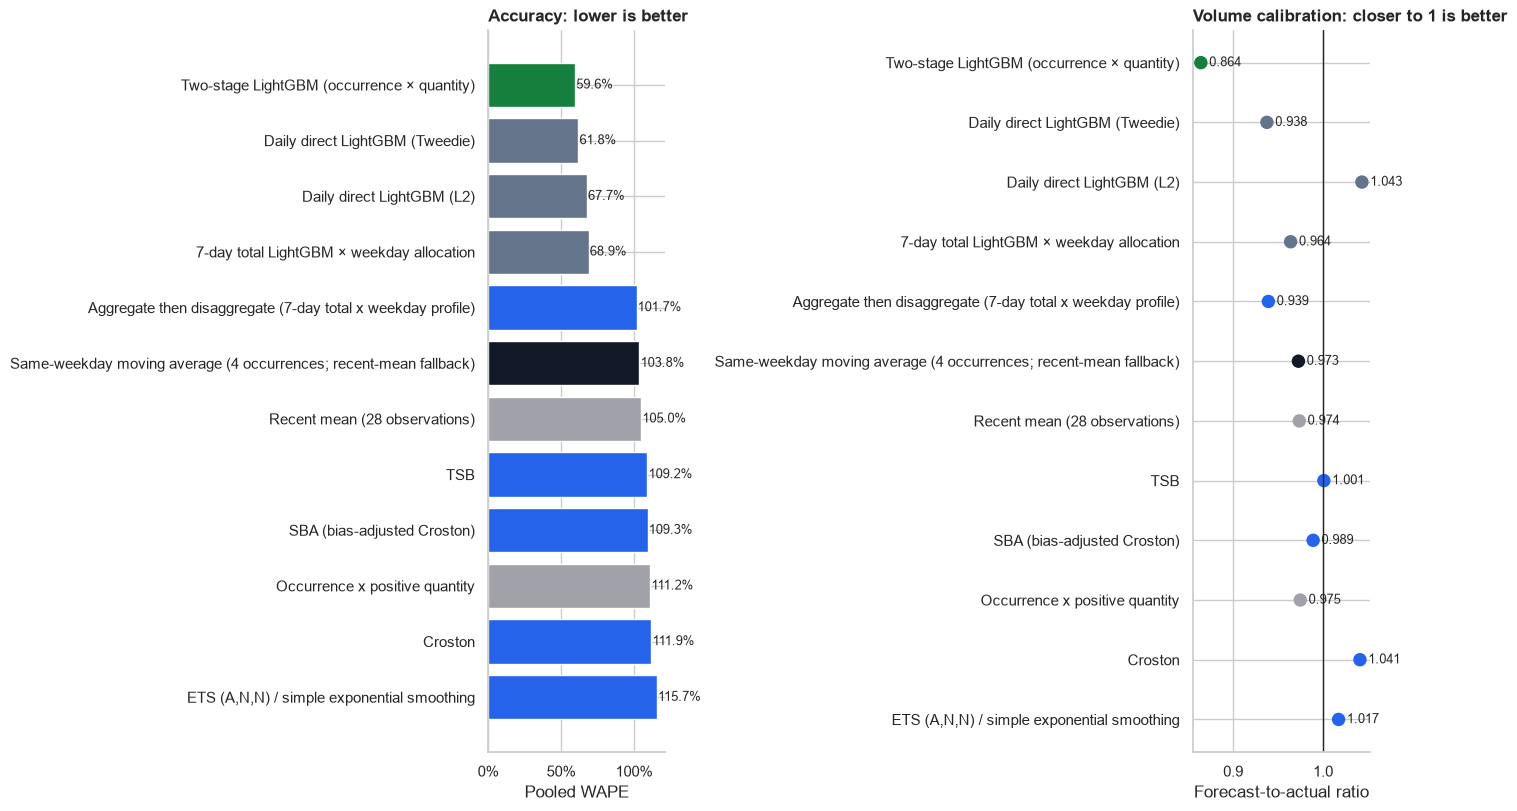

In [6]:
plot_summary = comparison_table.copy()
colors = [
    '#15803d' if model == ml_summary.iloc[0].model
    else '#64748b' if model in ML_MODELS
    else '#111827' if model == PRIMARY_MODEL
    else '#2563eb' if model in BASELINE_MODEL_LABELS
    else '#a1a1aa'
    for model in plot_summary.model
]
fig, axes = plt.subplots(1, 2, figsize=(14, 8), constrained_layout=True)
axes[0].barh(plot_summary.model_label, plot_summary.pooled_wape, color=colors)
axes[0].invert_yaxis()
axes[0].xaxis.set_major_formatter(PercentFormatter(1))
axes[0].set_xlabel('Pooled WAPE')
axes[0].set_ylabel('')
axes[0].set_title('Accuracy: lower is better', loc='left', weight='bold')
for y, value in enumerate(plot_summary.pooled_wape):
    axes[0].text(value + .008, y, f'{value:.1%}', va='center', fontsize=9)
axes[1].axvline(1, color='#222222', linewidth=1)
axes[1].scatter(plot_summary.forecast_to_actual_ratio, plot_summary.model_label, c=colors, s=75)
axes[1].invert_yaxis()
axes[1].set_xlabel('Forecast-to-actual ratio')
axes[1].set_ylabel('')
axes[1].set_title('Volume calibration: closer to 1 is better', loc='left', weight='bold')
for y, value in enumerate(plot_summary.forecast_to_actual_ratio):
    axes[1].annotate(f'{value:.3f}', (value, y), xytext=(6, 0), textcoords='offset points', va='center', fontsize=9)
sns.despine(fig=fig)
plt.show()

## Stability across origins

In [7]:
origin_results = segment_wape(all_forecasts, 'origin')
origin_wide = origin_results.pivot(index='origin', columns='model', values='pooled_wape')
origin_rows = []
for model in ML_MODELS:
    delta = origin_wide[model] - origin_wide[best_reference.model]
    origin_rows.append({
        'model': model,
        'model_label': LIGHTGBM_MODEL_LABELS[model],
        'origins_won_vs_best_reference': delta.lt(0).sum(),
        'origins_evaluated': delta.notna().sum(),
        'mean_wape_delta_pp': 100 * delta.mean(),
        'worst_wape_delta_pp': 100 * delta.max(),
    })
origin_summary = pd.DataFrame(origin_rows).sort_values('mean_wape_delta_pp')
display(origin_summary.style.format({
    'origins_won_vs_best_reference': '{:,.0f}', 'origins_evaluated': '{:,.0f}',
    'mean_wape_delta_pp': '{:+.2f}', 'worst_wape_delta_pp': '{:+.2f}',
}))

,model,model_label,origins_won_vs_best_reference,origins_evaluated,mean_wape_delta_pp,worst_wape_delta_pp
2,global_lightgbm_two_stage,Two-stage LightGBM (occurrence × quantity),9,9,-43.81,-21.35
1,global_lightgbm_tweedie_daily,Daily direct LightGBM (Tweedie),9,9,-41.40,-21.59
0,global_lightgbm,Daily direct LightGBM (L2),9,9,-35.42,-16.92
3,global_lightgbm_weekly_total,7-day total LightGBM × weekday allocation,9,9,-34.05,-13.56


## Business segments: accuracy and forecast volume

The four requested reporting segments combine `sourcing_group` with `category_id`. Each segment shows the four LightGBM architectures, the fixed primary benchmark, the globally best extended baseline, and—if different—the globally best non-ML reference. Keeping the comparator fixed avoids selecting a different baseline after seeing each segment's test result. Actual kilograms are common across models; forecasted kilograms and the forecast-to-actual ratio expose each architecture's volume behavior.

In [8]:
business = segment_wape(all_forecasts, 'business_segment')
business_reference = (
    business.loc[
        business.model.eq(best_reference.model),
        ['business_segment', 'pooled_wape'],
    ]
    .rename(columns={'pooled_wape': 'best_reference_wape'})
)
business_models = [
    *ML_MODELS, PRIMARY_MODEL, best_baseline.model, best_reference.model,
]
business_comparison = (
    business.loc[business.model.isin(business_models)]
    .merge(business_reference, on='business_segment', validate='m:1')
)
business_comparison['model_label'] = business_comparison.model.map(MODEL_LABELS)
business_comparison['forecasted_kg'] = (
    business_comparison.actual_kg * business_comparison.forecast_to_actual_ratio
)
business_comparison['gain_vs_best_reference_pp'] = 100 * (
    business_comparison.best_reference_wape - business_comparison.pooled_wape
)
business_comparison = business_comparison.sort_values(
    ['business_segment', 'pooled_wape']
)
display(business_comparison[[
    'business_segment', 'model_label', 'pooled_wape',
    'forecast_to_actual_ratio', 'actual_kg', 'forecasted_kg',
    'gain_vs_best_reference_pp',
]].style.format({
    'pooled_wape': '{:.2%}', 'forecast_to_actual_ratio': '{:.3f}',
    'actual_kg': '{:,.1f}', 'forecasted_kg': '{:,.1f}',
    'gain_vs_best_reference_pp': '{:+.2f}',
}))

,business_segment,model_label,pooled_wape,forecast_to_actual_ratio,actual_kg,forecasted_kg,gain_vs_best_reference_pp
4,FCM 890,7-day total LightGBM × weekday allocation,306.55%,2.111,37.4,79.0,+58.28
0,FCM 890,Aggregate then disaggregate (7-day total x weekday profile),364.83%,2.704,37.4,101.3,+0.00
5,FCM 890,Same-weekday moving average (4 occurrences; recent-mean fallback),370.12%,2.752,37.4,103.1,-5.29
3,FCM 890,Two-stage LightGBM (occurrence × quantity),372.23%,2.784,37.4,104.3,-7.40
2,FCM 890,Daily direct LightGBM (Tweedie),372.44%,2.783,37.4,104.2,-7.61
1,FCM 890,Daily direct LightGBM (L2),492.53%,4.001,37.4,149.8,-127.70
9,FCM 900,Two-stage LightGBM (occurrence × quantity),81.57%,0.885,"23,506.8","20,814.7",+15.95
8,FCM 900,Daily direct LightGBM (Tweedie),88.90%,1.064,"23,506.8","25,012.1",+8.61
7,FCM 900,Daily direct LightGBM (L2),92.91%,1.141,"23,506.8","26,809.8",+4.60
6,FCM 900,Aggregate then disaggregate (7-day total x weekday profile),97.52%,0.979,"23,506.8","23,013.3",+0.00


## Why the architectures differ

In [9]:
diagnostic = ml_forecasts.copy()
diagnostic['abs_error'] = (diagnostic.forecast - diagnostic.actual).abs()
diagnostic['zero_target_error'] = np.where(diagnostic.actual.eq(0), diagnostic.abs_error, 0.0)
diagnostic['positive_target_error'] = np.where(diagnostic.actual.gt(0), diagnostic.abs_error, 0.0)
diagnostic['near_zero_forecast'] = diagnostic.forecast.le(1e-8)
error_decomposition = (
    diagnostic.groupby('model', observed=True)
    .agg(
        actual_kg=('actual', 'sum'), forecasted_kg=('forecast', 'sum'),
        absolute_error_kg=('abs_error', 'sum'),
        error_on_zero_targets_kg=('zero_target_error', 'sum'),
        error_on_positive_targets_kg=('positive_target_error', 'sum'),
        near_zero_forecast_share=('near_zero_forecast', 'mean'),
    ).reset_index()
)
error_decomposition['model_label'] = error_decomposition.model.map(LIGHTGBM_MODEL_LABELS)
error_decomposition['forecast_to_actual_ratio'] = error_decomposition.forecasted_kg / error_decomposition.actual_kg
error_decomposition['zero_target_error_share'] = error_decomposition.error_on_zero_targets_kg / error_decomposition.absolute_error_kg
display(error_decomposition[[
    'model_label', 'actual_kg', 'forecasted_kg', 'forecast_to_actual_ratio',
    'absolute_error_kg', 'error_on_zero_targets_kg',
    'error_on_positive_targets_kg', 'zero_target_error_share',
    'near_zero_forecast_share',
]].sort_values('absolute_error_kg').style.format({
    'actual_kg': '{:,.1f}', 'forecasted_kg': '{:,.1f}',
    'forecast_to_actual_ratio': '{:.3f}', 'absolute_error_kg': '{:,.1f}',
    'error_on_zero_targets_kg': '{:,.1f}', 'error_on_positive_targets_kg': '{:,.1f}',
    'zero_target_error_share': '{:.1%}', 'near_zero_forecast_share': '{:.1%}',
}))

,model_label,actual_kg,forecasted_kg,forecast_to_actual_ratio,absolute_error_kg,error_on_zero_targets_kg,error_on_positive_targets_kg,zero_target_error_share,near_zero_forecast_share
2,Two-stage LightGBM (occurrence × quantity),"1,156,111.7","999,009.7",0.864,"689,149.0","101,363.5","587,785.5",14.7%,0.0%
1,Daily direct LightGBM (Tweedie),"1,156,111.7","1,083,896.7",0.938,"714,864.0","113,068.6","601,795.4",15.8%,0.0%
0,Daily direct LightGBM (L2),"1,156,111.7","1,206,002.2",1.043,"782,367.2","169,785.9","612,581.3",21.7%,1.4%
3,7-day total LightGBM × weekday allocation,"1,156,111.7","1,114,363.3",0.964,"796,960.5","153,246.1","643,714.4",19.2%,18.0%


,model_label,stage,feature,gain_share,splits
0,Daily direct LightGBM (L2),single model,action_on_forecast_day,24.7%,107
1,Daily direct LightGBM (L2),single model,ADI,20.2%,311
2,Daily direct LightGBM (L2),single model,demand_day_ratio,14.3%,277
3,Daily direct LightGBM (L2),single model,zero_share,11.1%,238
4,Daily direct LightGBM (L2),single model,ARTIKEL_ID,10.3%,"1,250"
5,Daily direct LightGBM (Tweedie),single model,action_on_forecast_day,35.6%,662
6,Daily direct LightGBM (Tweedie),single model,ARTIKEL_ID,22.0%,"6,724"
7,Daily direct LightGBM (Tweedie),single model,MARKT_ID,10.9%,"8,113"
8,Daily direct LightGBM (Tweedie),single model,days_since_last_positive_sale,7.0%,812
9,Daily direct LightGBM (Tweedie),single model,action_during_horizon,5.4%,308


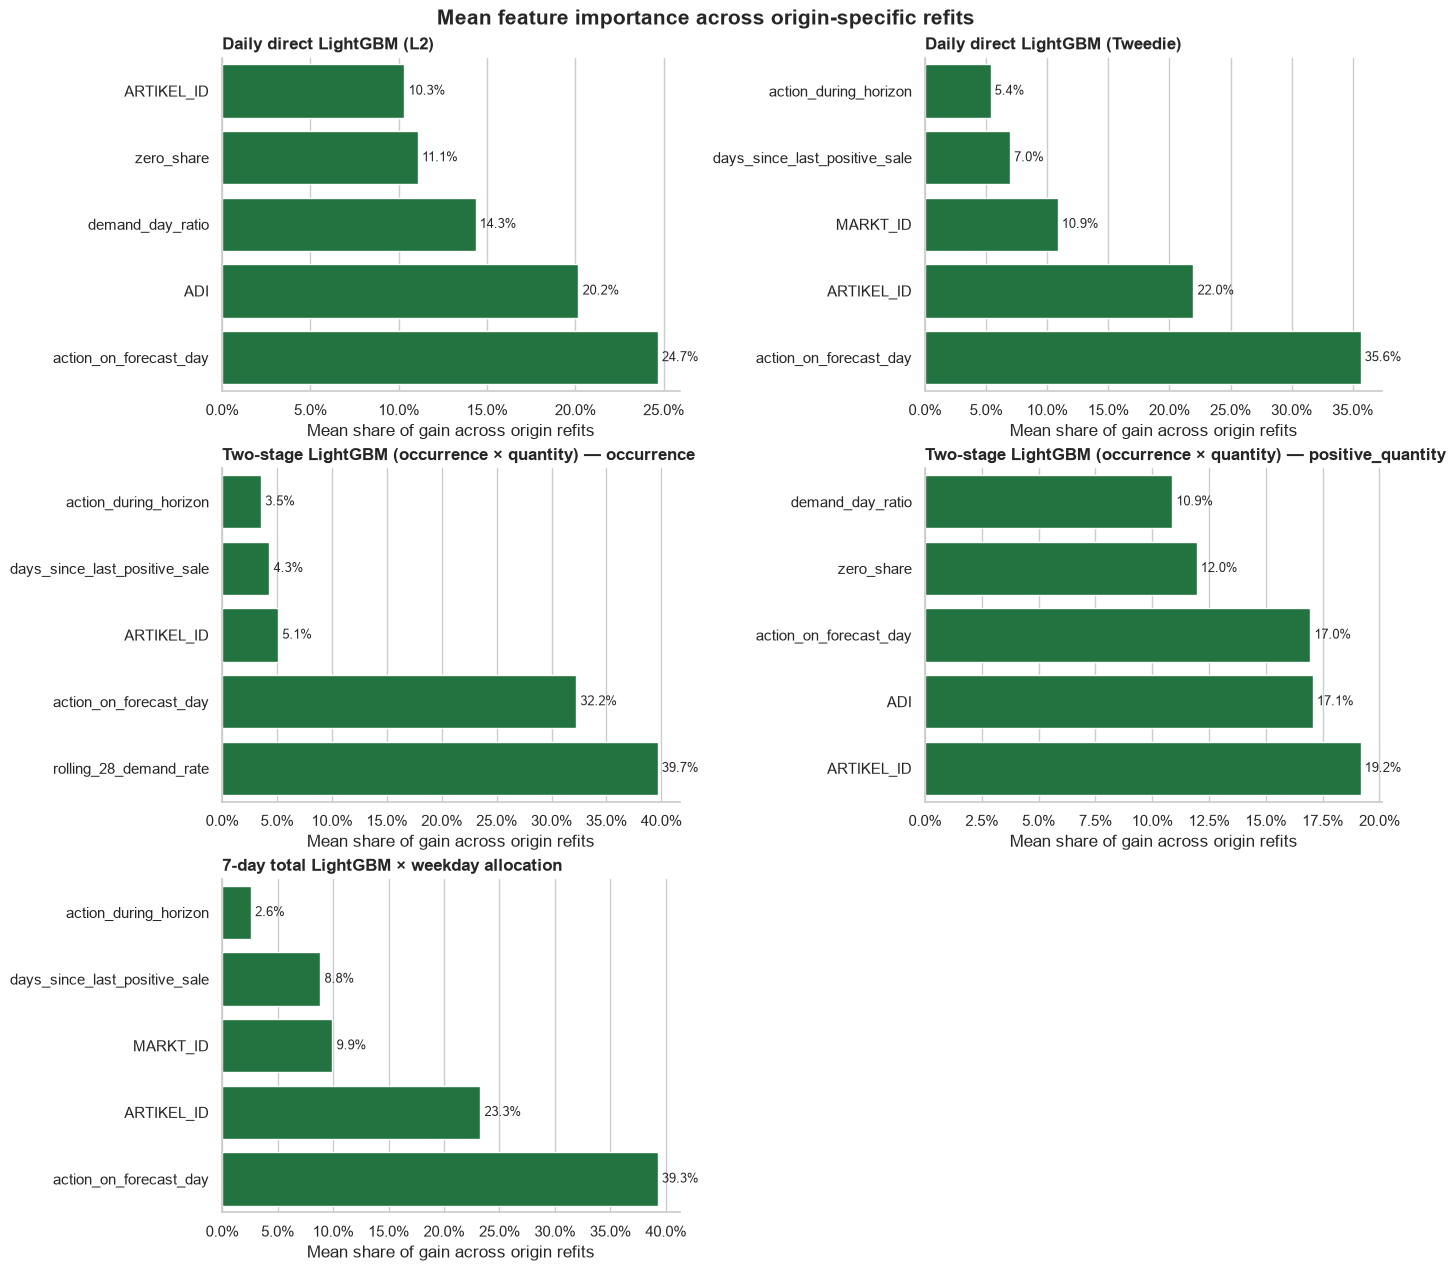

In [10]:
importance_rows = []
for model, result in model_results.items():
    importance = result.feature_importance.copy()
    if 'stage' not in importance:
        importance['stage'] = 'single model'
    importance = (
        importance.groupby(['stage', 'feature'], observed=True)
        .agg(gain_share=('gain_share', 'mean'), splits=('splits', 'mean'))
        .reset_index()
    )
    importance['model'] = model
    importance['model_label'] = LIGHTGBM_MODEL_LABELS[model]
    importance_rows.append(
        importance.sort_values('gain_share', ascending=False)
        .groupby('stage', observed=True).head(5)
    )
top_importance = pd.concat(importance_rows, ignore_index=True)
display(top_importance[[
    'model_label', 'stage', 'feature', 'gain_share', 'splits',
]].style.format({'gain_share': '{:.1%}', 'splits': '{:,.0f}'}))

importance_panels = list(
    top_importance.groupby(['model_label', 'stage'], sort=False, observed=True)
)
ncols = 2
nrows = int(np.ceil(len(importance_panels) / ncols))
fig, axes = plt.subplots(
    nrows, ncols, figsize=(14, 4.2 * nrows), squeeze=False,
    constrained_layout=True,
)
for ax, ((model_label, stage), panel) in zip(axes.flat, importance_panels):
    panel = panel.sort_values('gain_share', ascending=True)
    sns.barplot(
        data=panel, x='gain_share', y='feature',
        color='#15803d', ax=ax,
    )
    ax.xaxis.set_major_formatter(PercentFormatter(1))
    ax.set_xlabel('Mean share of gain across origin refits')
    ax.set_ylabel('')
    stage_suffix = '' if stage == 'single model' else f' — {stage}'
    ax.set_title(f'{model_label}{stage_suffix}', loc='left', weight='bold')
    ax.bar_label(
        ax.containers[0], labels=[f'{value:.1%}' for value in panel.gain_share],
        padding=3, fontsize=9,
    )
for ax in axes.flat[len(importance_panels):]:
    ax.set_visible(False)
fig.suptitle(
    'Mean feature importance across origin-specific refits',
    fontsize=15, weight='bold',
)
sns.despine(fig=fig)
plt.show()

In [11]:
weekly_audit = model_results[WEEKLY_MODEL_NAME].allocation_audit
allocation_summary = pd.DataFrame([{
    'series_origins': len(weekly_audit),
    'max_allocation_error_kg': weekly_audit.allocation_error.max(),
    'max_weekday_share_deviation': (weekly_audit.weekday_share_sum - 1).abs().max(),
}])
display(allocation_summary.style.format({
    'series_origins': '{:,.0f}', 'max_allocation_error_kg': '{:.3e}',
    'max_weekday_share_deviation': '{:.3e}',
}))

,series_origins,max_allocation_error_kg,max_weekday_share_deviation
0,"220,288",1.137e-13,2.220e-16
